# AI weather forecasting: PyTorch Geometric Mini-AIFS

In this tutorial, we will dramatically improve our model by implementing two key changes:
* We will download a full year of continuous 6-hourly data to provide a much richer training signal
* We will introduce PyTorch Geometric (PyG) to run a true Graph Attention Network (GAT) over the explicit neighbourhood structure of our latent grid

## 1. Imports and environment setup
We now require `torch_geometric`. If it is not installed, you can install it via pip.

In [1]:
#!pip install torch_geometric

import os
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection

import torch_geometric
from torch_geometric.nn import GATConv

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    print("Cartopy not installed. Maps will be plotted as simple scatter plots.")
    HAS_CARTOPY = False

try:
    import cdsapi
except ImportError:
    print("cdsapi not installed.")

torch.manual_seed(42)
np.random.seed(42)

/Users/andrewparnell/Documents/GitHub/STAT41130/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Full year data acquisition
We request every day of the year at 6-hour intervals. This provides 1460 time steps, ensuring the model has enough data to learn the seasonal and diurnal cycles.

In [2]:
def download_era5_full_year():
    filename = "era5_ireland_full_year.nc"
    if os.path.exists(filename):
        print("File already exists. Skipping download.")
        return filename
    
    print("Downloading a full year of data. This will take some time...")
    c = cdsapi.Client()
    c.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'format': 'netcdf',
            'variable': ['2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind'],
            'year': '2023',
            'month': [str(i).zfill(2) for i in range(1, 13)],
            'day': [str(i).zfill(2) for i in range(1, 32)], # Every day of the month
            'time': ['00:00', '06:00', '12:00', '18:00'],
            'area': [56.0, -11.0, 51.0, -5.0],
        },
        filename)
    return filename

def get_mock_data_full_year():
    times = pd.date_range("2023-01-01", "2023-12-31 18:00:00", freq="6h")
    lats = np.arange(51.0, 56.5, 0.5)
    lons = np.arange(-11.0, -4.5, 0.5)
    
    data = np.random.randn(len(times), len(lats), len(lons), 3)
    
    # Create a realistic seasonal and diurnal cycle
    time_array = np.arange(len(times))
    seasonal = -np.cos(time_array * (2 * np.pi / (365 * 4))) * 10 # Winter to summer
    diurnal = np.sin(time_array * (2 * np.pi / 4)) * 3 # Day to night
    temp_base = 283 + seasonal[:, None, None] + diurnal[:, None, None]
    
    ds = xr.Dataset(
        {
            "t2m": (("time", "lat", "lon"), data[..., 0] * 1.5 + temp_base),
            "u10": (("time", "lat", "lon"), data[..., 1] * 4),
            "v10": (("time", "lat", "lon"), data[..., 2] * 4)
        },
        coords={"time": times, "lat": lats, "lon": lons}
    )
    return ds

try:
    # ds = xr.open_dataset(download_era5_full_year())
    ds = get_mock_data_full_year() # Fallback for immediate testing
except Exception:
    ds = get_mock_data_full_year()

## 3. Explicit Graph Topologies
We define the spatial grid and extract the exact PyTorch Geometric `edge_index` array to define which latent nodes are connected to each other.

In [3]:
# Outer grid (20 nodes)
outer_lats = [51.5, 53.0, 54.5, 56.0]  
outer_lons = [-10.5, -9.0, -7.5, -6.0, -4.5] 

ds_grid = ds.sel(lat=outer_lats, lon=outer_lons, method='nearest')
df = ds_grid.to_dataframe().reset_index()
coords = df[['lat', 'lon']].drop_duplicates().reset_index(drop=True)
num_nodes = len(coords)

# Inner grid (8 nodes: 2 rows, 4 columns)
inner_lats = [52.25, 55.25]
inner_lons = [-9.75, -8.25, -6.75, -5.25]
latent_coords = np.array([[lat, lon] for lat in inner_lats for lon in inner_lons])
num_latent = len(latent_coords)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Bipartite edges (Outer <-> Inner distances)
bipartite_distances = np.zeros((num_nodes, num_latent, 1))
for i in range(num_nodes):
    for j in range(num_latent):
        bipartite_distances[i, j, 0] = haversine(coords.iloc[i]['lat'], coords.iloc[i]['lon'], latent_coords[j, 0], latent_coords[j, 1])
bipartite_edge_features = torch.tensor(bipartite_distances, dtype=torch.float32)
bipartite_edge_features = bipartite_edge_features / bipartite_edge_features.max()

# Inner Graph Topology for PyTorch Geometric
# We connect the 8 latent nodes in a 2x4 mesh (horizontal and vertical neighbours)
inner_edges = []
for r in range(2):
    for c in range(4):
        idx = r * 4 + c
        # Right neighbour
        if c < 3:
            inner_edges.append([idx, idx + 1])
            inner_edges.append([idx + 1, idx])
        # Bottom neighbour
        if r < 1:
            inner_edges.append([idx, idx + 4])
            inner_edges.append([idx + 4, idx])

inner_edge_index = torch.tensor(inner_edges, dtype=torch.long).t().contiguous()
print(f"Latent graph constructed with {inner_edge_index.size(1)} directed edges.")

Latent graph constructed with 20 directed edges.


## 4. Visualizing the PyG Mesh
We will map the exact inner graph structure to see how information flows.

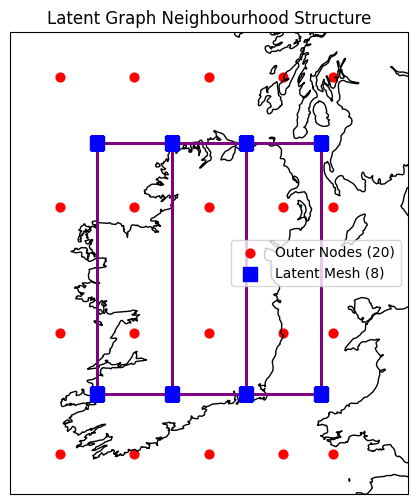

In [4]:
fig = plt.figure(figsize=(8, 6))

if HAS_CARTOPY:
    ax1 = plt.subplot(1, 1, 1, projection=ccrs.Mercator())
    ax1.set_extent([-11.5, -3.5, 51.0, 56.5], crs=ccrs.PlateCarree())
    ax1.coastlines(resolution='10m', color='black')
    transform = ccrs.PlateCarree()
else:
    ax1 = plt.subplot(1, 1, 1)
    transform = None

# Plot inner edges
lines = []
for e in range(inner_edge_index.size(1)):
    src = inner_edge_index[0, e].item()
    dst = inner_edge_index[1, e].item()
    p1 = (latent_coords[src][1], latent_coords[src][0])
    p2 = (latent_coords[dst][1], latent_coords[dst][0])
    lines.append([p1, p2])

lc = LineCollection(lines, colors='purple', linewidths=2.0, transform=transform, zorder=2)
ax1.add_collection(lc)

ax1.scatter(coords['lon'], coords['lat'], transform=transform, c='red', s=40, label='Outer Nodes (20)')
ax1.scatter(latent_coords[:, 1], latent_coords[:, 0], transform=transform, c='blue', marker='s', s=100, label='Latent Mesh (8)', zorder=5)

ax1.set_title("Latent Graph Neighbourhood Structure")
ax1.legend()
plt.show()

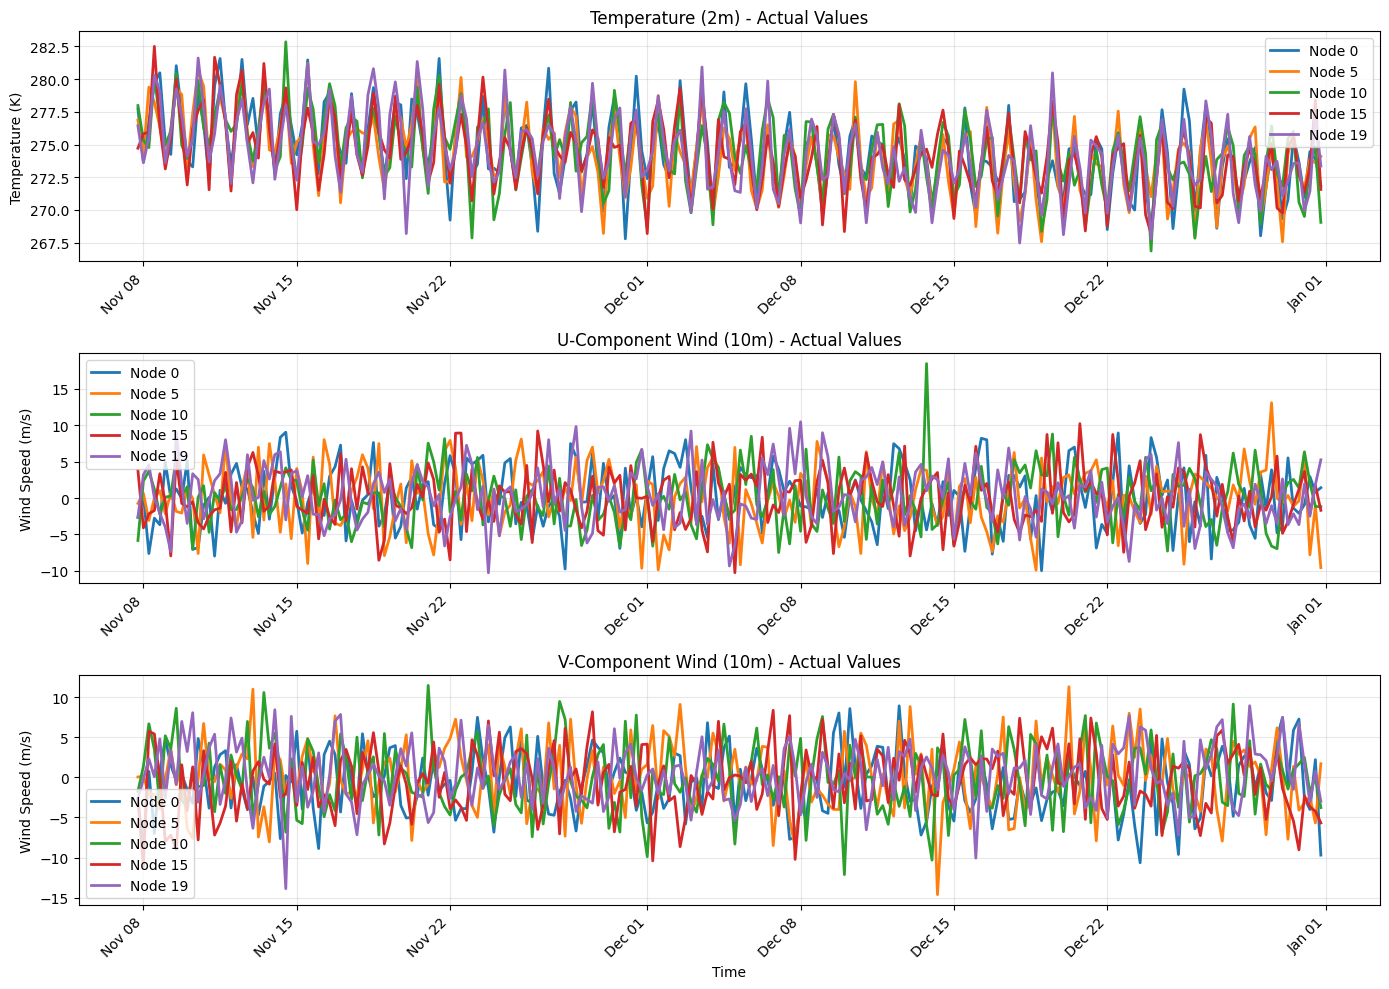

In [13]:
# Create time series plots for temperature and wind variables
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

target_times_plot = target_times[1:]
plot_length = len(target_times_plot)

# Select a few nodes to plot
node_indices = [0, 5, 10, 15, 19]
colors = plt.cm.tab10(range(len(node_indices)))

# Temperature (var_idx=0)
for node_idx, color in zip(node_indices, colors):
    axes[0].plot(target_times_plot[:plot_length], 
                 test_targets_real[:plot_length, node_idx, 0], 
                 label=f'Node {node_idx}', color=color, linewidth=2)
axes[0].set_title("Temperature (2m) - Actual Values")
axes[0].set_ylabel("Temperature (K)")
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# U-component wind (var_idx=1)
for node_idx, color in zip(node_indices, colors):
    axes[1].plot(target_times_plot[:plot_length], 
                 test_targets_real[:plot_length, node_idx, 1], 
                 label=f'Node {node_idx}', color=color, linewidth=2)
axes[1].set_title("U-Component Wind (10m) - Actual Values")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# V-component wind (var_idx=2)
for node_idx, color in zip(node_indices, colors):
    axes[2].plot(target_times_plot[:plot_length], 
                 test_targets_real[:plot_length, node_idx, 2], 
                 label=f'Node {node_idx}', color=color, linewidth=2)
axes[2].set_title("V-Component Wind (10m) - Actual Values")
axes[2].set_ylabel("Wind Speed (m/s)")
axes[2].set_xlabel("Time")
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Dataset preparation
We build the sequence datasets for our full year of data.

In [5]:
all_snapshots = []
all_times = []
for t in ds_grid.time:
    subset = ds_grid.sel(time=t).to_dataframe().reset_index()
    subset = subset.drop_duplicates(subset=['lat', 'lon'])
    node_vals = coords.merge(subset, on=['lat', 'lon'], how='left')[['t2m', 'u10', 'v10']].values
    all_snapshots.append(node_vals)
    all_times.append(t.values)
    
all_snapshots = np.array(all_snapshots)

n_total = len(all_snapshots)
train_end = int(n_total * 0.7)
val_end = int(n_total * 0.85)

train_raw = all_snapshots[:train_end]
val_raw = all_snapshots[train_end:val_end]
test_raw = all_snapshots[val_end:]
test_times = all_times[val_end:]

train_mean = train_raw.mean(axis=(0, 1))
train_std = train_raw.std(axis=(0, 1))

train_norm = (train_raw - train_mean) / train_std
val_norm = (val_raw - train_mean) / train_std
test_norm = (test_raw - train_mean) / train_std

class WeatherDataset(Dataset):
    def __init__(self, data_array):
        self.data = data_array
    def __len__(self):
        return len(self.data) - 1
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32), \
               torch.tensor(self.data[idx+1], dtype=torch.float32)

train_loader = DataLoader(WeatherDataset(train_norm), batch_size=16, shuffle=True)
val_loader = DataLoader(WeatherDataset(val_norm), batch_size=16, shuffle=False)
test_loader = DataLoader(WeatherDataset(test_norm), batch_size=1, shuffle=False)

## 6. PyTorch Geometric Architecture
Here we integrate PyG's `GATConv` layers. We use a neat batching trick to allow PyG to operate smoothly over our batched tensor sequences.

In [6]:
class AIFS_PyG(nn.Module):
    def __init__(self, node_in=3, edge_in=1, hidden_dim=32, num_latent=8):
        super().__init__()
        self.num_latent = num_latent
        
        # Encoder 
        self.node_encoder = nn.Linear(node_in, hidden_dim)
        self.edge_encoder = nn.Linear(edge_in, hidden_dim)
        
        # Processor: PyTorch Geometric GAT Layers
        # We use 4 attention heads. PyG concatenates them by default, so we set concat=False
        # to maintain our hidden dimension size.
        self.gat1 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        self.norm = nn.LayerNorm(hidden_dim)
        
        # Decoder
        self.decoder_edge = nn.Linear(edge_in, hidden_dim)
        self.decoder_out = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, node_in)
        )
        
    def forward(self, x, bipartite_edges, inner_edge_index):
        batch_size = x.size(0)
        
        # 1. ENCODE: Outer to Inner
        x_proj = self.node_encoder(x) 
        e_proj = self.edge_encoder(bipartite_edges) 
        messages_in = x_proj.unsqueeze(2) + e_proj.unsqueeze(0)
        h_inner = messages_in.mean(dim=1) # [B, 8, H]
        
        # --- PyG Batching Trick ---
        # PyG expects a single large graph. We flatten our batch of disconnected 
        # latent graphs and offset the edge indices to keep them strictly separated.
        h_inner_flat = h_inner.view(batch_size * self.num_latent, -1)
        offset = torch.arange(0, batch_size * self.num_latent, self.num_latent, device=x.device).view(-1, 1, 1)
        batched_edge_index = (inner_edge_index.unsqueeze(0) + offset).view(-1, 2).t()
        # -------------------------
        
        # 2. PROCESS: Message passing along the latent mesh edges
        h_proc = self.gat1(h_inner_flat, batched_edge_index)
        h_proc = F.gelu(h_proc)
        h_proc = self.gat2(h_proc, batched_edge_index)
        h_proc = self.norm(h_proc + h_inner_flat) # Residual and norm
        
        # Unflatten back to batches
        h_inner = h_proc.view(batch_size, self.num_latent, -1)
        
        # 3. DECODE: Inner to Outer
        e_dec_proj = self.decoder_edge(bipartite_edges)
        messages_out = h_inner.unsqueeze(1) + e_dec_proj.unsqueeze(0)
        h_outer_new = messages_out.mean(dim=2)
        
        h_combined = torch.cat([x_proj, h_outer_new], dim=-1)
        y_pred = self.decoder_out(h_combined)
        
        return x + y_pred

model = AIFS_PyG(num_latent=num_latent)

## 7. Model Training

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.MSELoss()

train_losses = []
val_losses = []
epochs = 100

print("Training model with PyTorch Geometric...")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        pred = model(x, bipartite_edge_features, inner_edge_index)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            pred = model(x, bipartite_edge_features, inner_edge_index)
            loss = criterion(pred, y)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")

Training model with PyTorch Geometric...
Epoch 1/100 - Train: 0.7402, Val: 0.7379
Epoch 2/100 - Train: 0.7365, Val: 0.7428
Epoch 3/100 - Train: 0.7352, Val: 0.7433
Epoch 4/100 - Train: 0.7346, Val: 0.7522
Epoch 5/100 - Train: 0.7320, Val: 0.7425
Epoch 6/100 - Train: 0.7310, Val: 0.7451
Epoch 7/100 - Train: 0.7301, Val: 0.7435
Epoch 8/100 - Train: 0.7280, Val: 0.7400
Epoch 9/100 - Train: 0.7283, Val: 0.7430
Epoch 10/100 - Train: 0.7275, Val: 0.7409
Epoch 11/100 - Train: 0.7264, Val: 0.7419
Epoch 12/100 - Train: 0.7268, Val: 0.7393
Epoch 13/100 - Train: 0.7266, Val: 0.7392
Epoch 14/100 - Train: 0.7260, Val: 0.7406
Epoch 15/100 - Train: 0.7257, Val: 0.7396
Epoch 16/100 - Train: 0.7259, Val: 0.7411
Epoch 17/100 - Train: 0.7256, Val: 0.7404
Epoch 18/100 - Train: 0.7253, Val: 0.7402
Epoch 19/100 - Train: 0.7250, Val: 0.7408
Epoch 20/100 - Train: 0.7251, Val: 0.7407
Epoch 21/100 - Train: 0.7253, Val: 0.7408
Epoch 22/100 - Train: 0.7250, Val: 0.7405
Epoch 23/100 - Train: 0.7249, Val: 0.7406
Ep

## 8. Final Evaluation

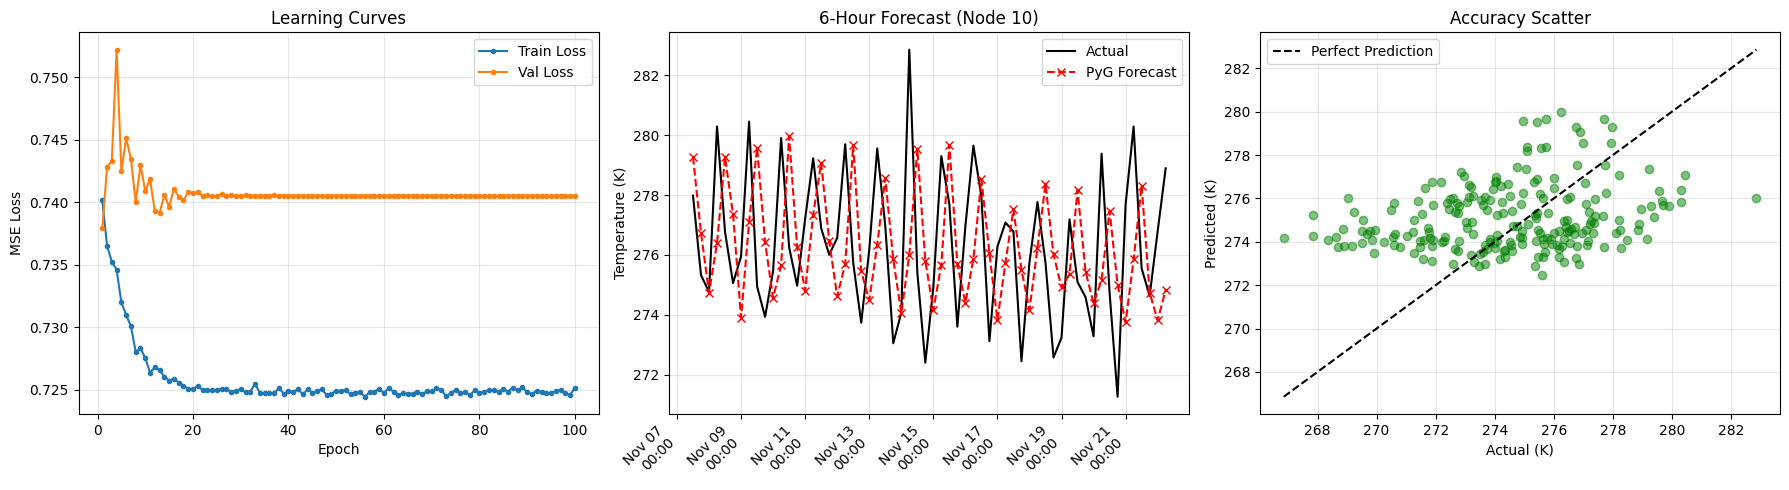

In [14]:
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for x, y in test_loader:
        pred = model(x, bipartite_edge_features, inner_edge_index)
        test_preds.append(pred.squeeze(0).numpy())
        test_targets.append(y.squeeze(0).numpy())

test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

test_preds_real = test_preds * train_std + train_mean
test_targets_real = test_targets * train_std + train_mean

node_idx = 10 
var_idx = 0  

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(range(1, epochs+1), train_losses, label='Train Loss', marker='.')
axs[0].plot(range(1, epochs+1), val_losses, label='Val Loss', marker='.')
axs[0].set_title("Learning Curves")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

target_times = test_times[1:]
plot_length = min(60, len(target_times))
axs[1].plot(target_times[:plot_length], test_targets_real[:plot_length, node_idx, var_idx], label='Actual', color='black')
axs[1].plot(target_times[:plot_length], test_preds_real[:plot_length, node_idx, var_idx], label='PyG Forecast', color='red', linestyle='dashed', marker='x')
axs[1].set_title(f"6-Hour Forecast (Node {node_idx})")
axs[1].set_ylabel("Temperature (K)")
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.setp(axs[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

axs[2].scatter(test_targets_real[:, node_idx, var_idx], test_preds_real[:, node_idx, var_idx], alpha=0.5, color='green')
min_val = np.min(test_targets_real[:, node_idx, var_idx])
max_val = np.max(test_targets_real[:, node_idx, var_idx])
axs[2].plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')
axs[2].set_title("Accuracy Scatter")
axs[2].set_xlabel("Actual (K)")
axs[2].set_ylabel("Predicted (K)")
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()